# Exploratory Data Analysis — DataFrame

Generated by `flashkeras.notebooks`.

Edit the **Parameters** cell below with your CSV path and re-run everything (`Run All`).

In [1]:
csv_path = "data\\credit_risk_dataset.csv"
target_column = None  # optional: name of the column you want to predict
separator = ","


## 1. Setup

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 100)
plt.rcParams["figure.figsize"] = (10, 5)


## 2. Load data

In [3]:
df = pd.read_csv(csv_path, sep=separator)
print(f"Shape: {df.shape}")
df.head()


Shape: (32581, 12)


,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


## 3. Overview

In [4]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  32581 non-null  int64  
 1   person_income               32581 non-null  int64  
 2   person_home_ownership       32581 non-null  object 
 3   person_emp_length           31686 non-null  float64
 4   loan_intent                 32581 non-null  object 
 5   loan_grade                  32581 non-null  object 
 6   loan_amnt                   32581 non-null  int64  
 7   loan_int_rate               29465 non-null  float64
 8   loan_status                 32581 non-null  int64  
 9   loan_percent_income         32581 non-null  float64
 10  cb_person_default_on_file   32581 non-null  object 
 11  cb_person_cred_hist_length  32581 non-null  int64  
dtypes: float64(3), int64(5), object(4)
memory usage: 3.0+ MB


In [5]:
df.describe(include="all").T


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
person_age,32581.0,NaN,NaN,NaN,27.7346,6.348078,20.0,23.0,26.0,30.0,144.0
person_income,32581.0,NaN,NaN,NaN,66074.84847,61983.119168,4000.0,38500.0,55000.0,79200.0,6000000.0
person_home_ownership,32581,4,RENT,16446,NaN,NaN,NaN,NaN,NaN,NaN,NaN
person_emp_length,31686.0,NaN,NaN,NaN,4.789686,4.14263,0.0,2.0,4.0,7.0,123.0
loan_intent,32581,6,EDUCATION,6453,NaN,NaN,NaN,NaN,NaN,NaN,NaN
loan_grade,32581,7,A,10777,NaN,NaN,NaN,NaN,NaN,NaN,NaN
loan_amnt,32581.0,NaN,NaN,NaN,9589.371106,6322.086646,500.0,5000.0,8000.0,12200.0,35000.0
loan_int_rate,29465.0,NaN,NaN,NaN,11.011695,3.240459,5.42,7.9,10.99,13.47,23.22
loan_status,32581.0,NaN,NaN,NaN,0.218164,0.413006,0.0,0.0,0.0,0.0,1.0
loan_percent_income,32581.0,NaN,NaN,NaN,0.170203,0.106782,0.0,0.09,0.15,0.23,0.83


## 4. Missing values

,missing_count,missing_pct
loan_int_rate,3116,9.56
person_emp_length,895,2.75


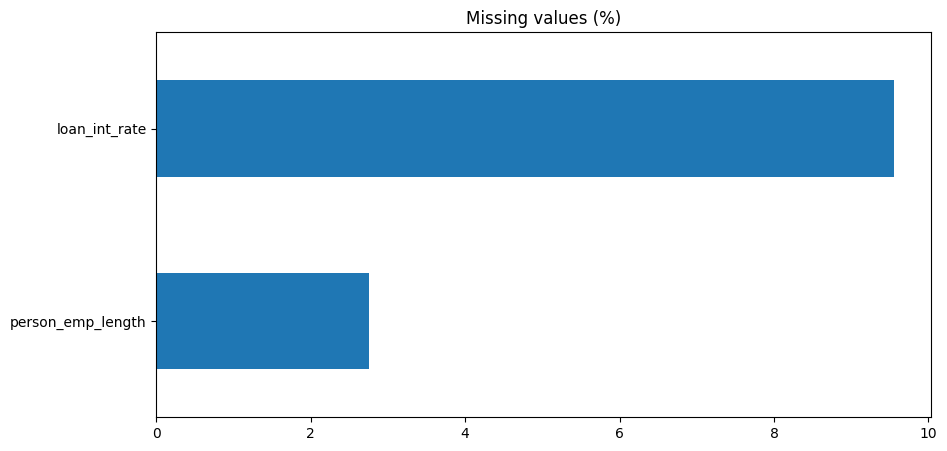

In [6]:
missing = df.isna().sum().sort_values(ascending=False)
missing = missing[missing > 0]

if missing.empty:
    print("No missing values found.")
else:
    missing_pct = (missing / len(df) * 100).round(2)
    missing_df = pd.DataFrame({"missing_count": missing, "missing_pct": missing_pct})
    display(missing_df)
    missing_df["missing_pct"].plot(kind="barh", title="Missing values (%)")
    plt.gca().invert_yaxis()
    plt.show()


## 5. Duplicates

In [7]:
n_dupes = df.duplicated().sum()
print(f"Duplicate rows: {n_dupes} ({n_dupes / len(df) * 100:.2f}%)")


Duplicate rows: 165 (0.51%)


## 6. Column types

In [8]:
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = df.select_dtypes(include=["object", "category", "bool"]).columns.tolist()
datetime_cols = df.select_dtypes(include=["datetime", "datetimetz"]).columns.tolist()

print(f"Numeric ({len(numeric_cols)}): {numeric_cols}")
print(f"Categorical ({len(categorical_cols)}): {categorical_cols}")
print(f"Datetime ({len(datetime_cols)}): {datetime_cols}")


Numeric (8): ['person_age', 'person_income', 'person_emp_length', 'loan_amnt', 'loan_int_rate', 'loan_status', 'loan_percent_income', 'cb_person_cred_hist_length']
Categorical (4): ['person_home_ownership', 'loan_intent', 'loan_grade', 'cb_person_default_on_file']
Datetime (0): []


## 7. Numeric distributions

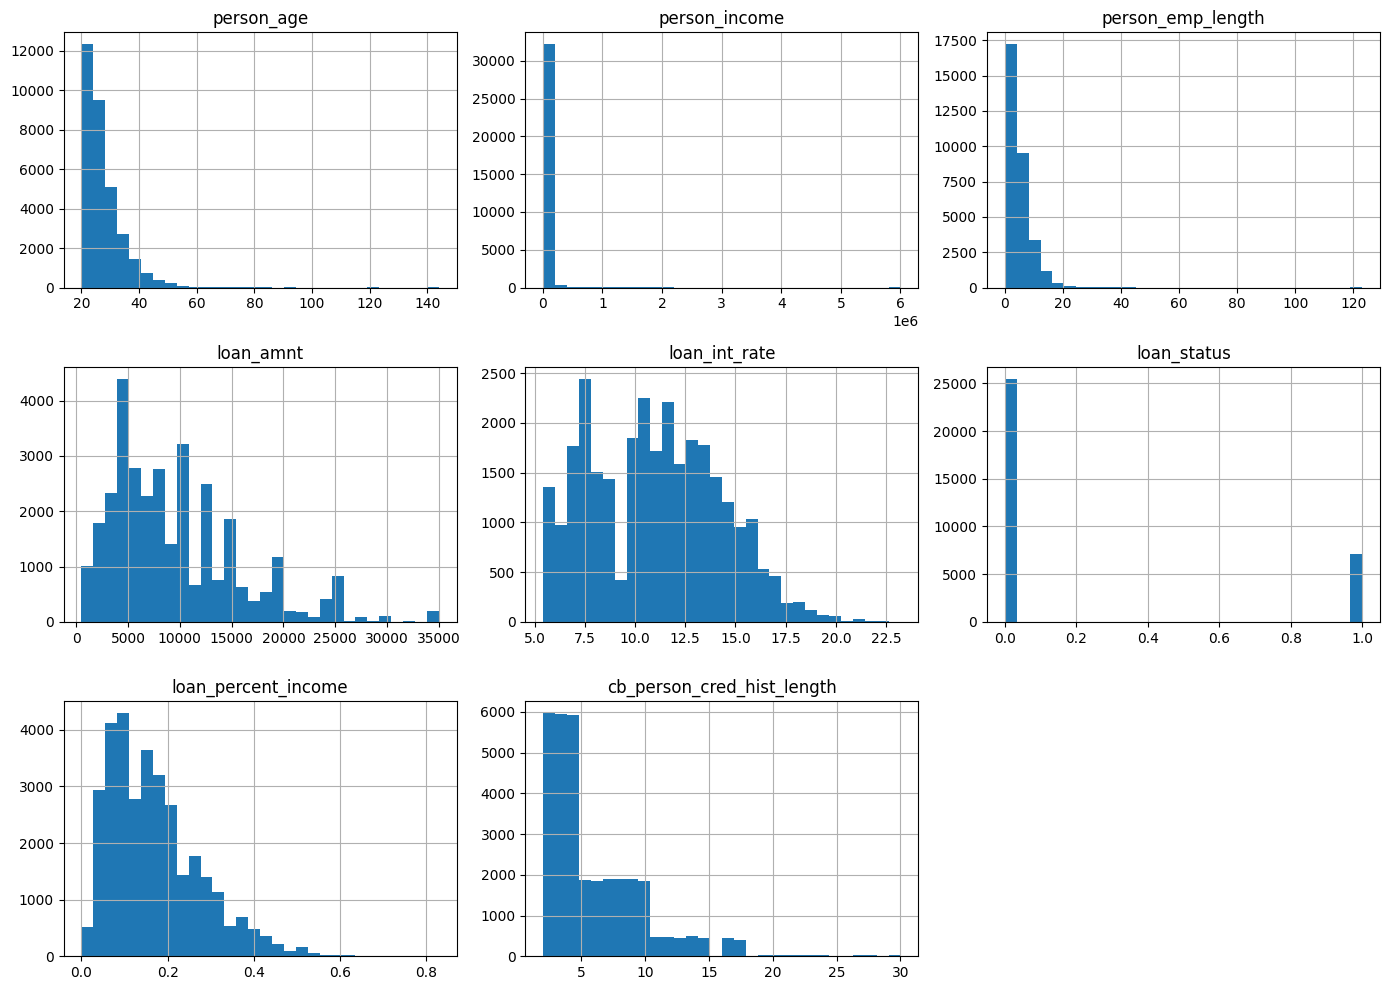

In [9]:
if numeric_cols:
    df[numeric_cols].hist(figsize=(14, 10), bins=30)
    plt.tight_layout()
    plt.show()
else:
    print("No numeric columns found.")


## 8. Categorical value counts (top columns)

In [10]:
for col in categorical_cols[:10]:
    print(f"\n--- {col} ---")
    print(df[col].value_counts(dropna=False).head(10))



--- person_home_ownership ---
person_home_ownership
RENT        16446
MORTGAGE    13444
OWN          2584
OTHER         107
Name: count, dtype: int64

--- loan_intent ---
loan_intent
EDUCATION            6453
MEDICAL              6071
VENTURE              5719
PERSONAL             5521
DEBTCONSOLIDATION    5212
HOMEIMPROVEMENT      3605
Name: count, dtype: int64

--- loan_grade ---
loan_grade
A    10777
B    10451
C     6458
D     3626
E      964
F      241
G       64
Name: count, dtype: int64

--- cb_person_default_on_file ---
cb_person_default_on_file
N    26836
Y     5745
Name: count, dtype: int64


## 9. Correlation matrix (numeric)

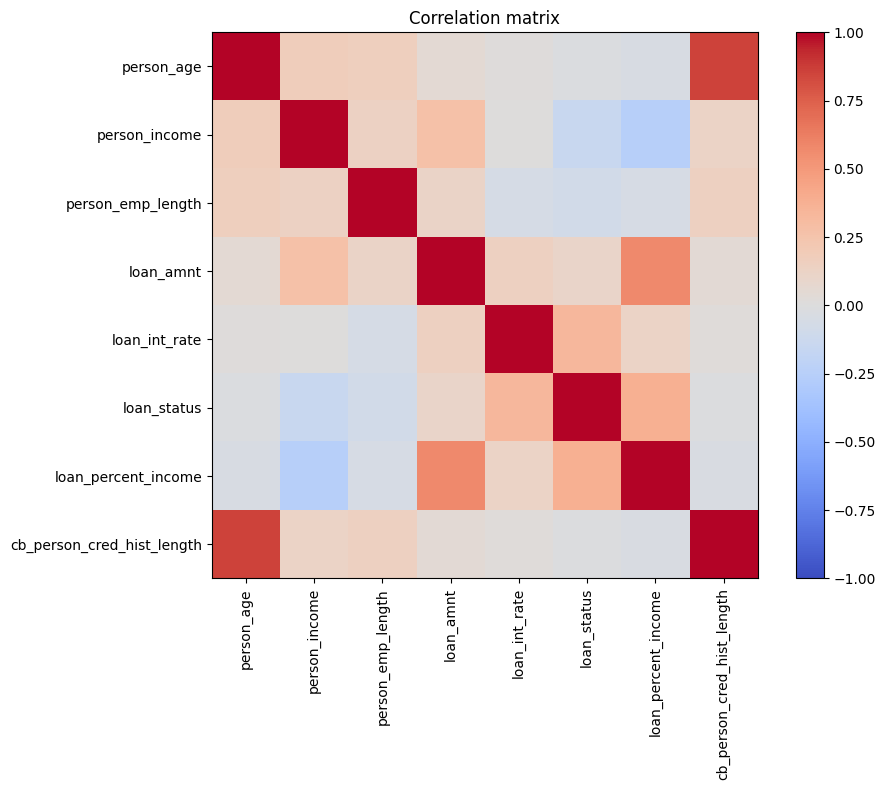

In [11]:
if len(numeric_cols) >= 2:
    corr = df[numeric_cols].corr()
    fig, ax = plt.subplots(figsize=(10, 8))
    im = ax.imshow(corr, cmap="coolwarm", vmin=-1, vmax=1)
    ax.set_xticks(range(len(corr.columns)))
    ax.set_yticks(range(len(corr.columns)))
    ax.set_xticklabels(corr.columns, rotation=90)
    ax.set_yticklabels(corr.columns)
    fig.colorbar(im)
    plt.title("Correlation matrix")
    plt.tight_layout()
    plt.show()
else:
    print("Not enough numeric columns for a correlation matrix.")


## 10. Numeric outlier detection

The IQR rule flags values below Q1 - 1.5 × IQR or above Q3 + 1.5 × IQR. Review the flagged percentage rather than treating every flagged value as an error.

,column,outlier_count,outlier_pct,lower_bound,upper_bound
5,loan_status,7108,21.82,0.000,0.000
3,loan_amnt,1689,5.18,-5800.000,23000.000
0,person_age,1494,4.59,12.500,40.500
1,person_income,1484,4.55,-22550.000,140250.000
7,cb_person_cred_hist_length,1142,3.51,-4.500,15.500
2,person_emp_length,853,2.62,-5.500,14.500
6,loan_percent_income,651,2.00,-0.120,0.440
4,loan_int_rate,6,0.02,-0.455,21.825


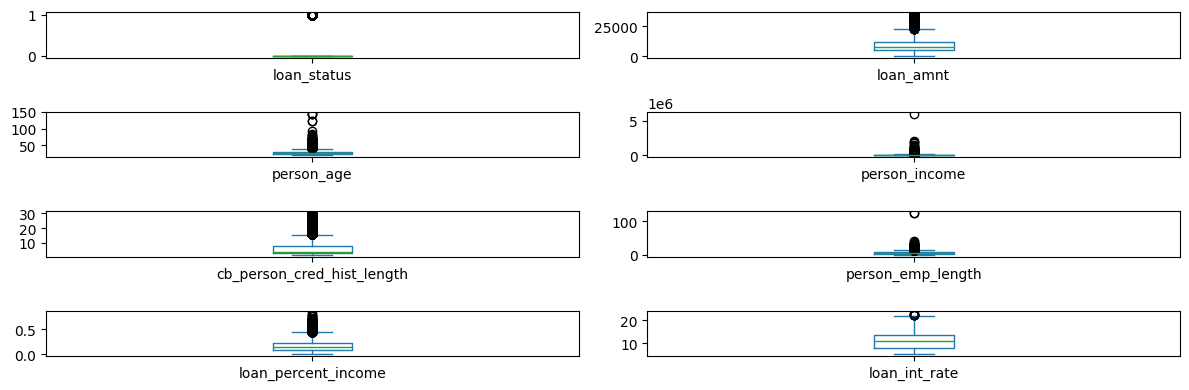

In [12]:
outlier_rows = []

for col in numeric_cols:
    values = df[col].dropna()
    if values.empty:
        continue

    q1 = values.quantile(0.25)
    q3 = values.quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    outlier_mask = (df[col] < lower_bound) | (df[col] > upper_bound)
    outlier_count = int(outlier_mask.sum())

    outlier_rows.append({
        "column": col,
        "outlier_count": outlier_count,
        "outlier_pct": round(outlier_count / len(df) * 100, 2),
        "lower_bound": lower_bound,
        "upper_bound": upper_bound,
    })

if outlier_rows:
    outlier_summary = pd.DataFrame(outlier_rows).sort_values("outlier_count", ascending=False)
    display(outlier_summary)

    columns_with_outliers = outlier_summary.loc[
        outlier_summary["outlier_count"] > 0, "column"
    ].tolist()
    if columns_with_outliers:
        df[columns_with_outliers].plot(kind="box", subplots=True, layout=(-1, 2), figsize=(12, 4))
        plt.tight_layout()
        plt.show()
    else:
        print("No numeric outliers found using the IQR rule.")
else:
    print("No numeric columns available for outlier detection.")

## 11. Target column analysis (if set)

In [13]:
if target_column is not None:
    print(f"Target: {target_column}")
    display(df[target_column].describe())

    if target_column in categorical_cols or df[target_column].nunique() < 20:
        df[target_column].value_counts().plot(kind="bar", title=f"Distribution of {target_column}")
        plt.show()
    else:
        df[target_column].plot(kind="hist", bins=30, title=f"Distribution of {target_column}")
        plt.show()
else:
    print("Set `target_column` in the Parameters cell to analyze it here.")


Set `target_column` in the Parameters cell to analyze it here.


## 12. Target balance (if set)

For classification targets, compare class percentages. A large difference between the most and least common classes may indicate imbalance; the appropriate threshold depends on the problem and evaluation metric.

In [14]:
if target_column is None:
    print("Set `target_column` in the Parameters cell to check class balance.")
else:
    target_counts = df[target_column].value_counts(dropna=False)
    target_percentages = (target_counts / len(df) * 100).round(2)
    balance_df = pd.DataFrame({
        "count": target_counts,
        "percentage": target_percentages,
    })
    display(balance_df)

    balance_df["percentage"].plot(kind="bar", title=f"Class distribution: {target_column}")
    plt.ylabel("Percentage of rows")
    plt.xlabel(target_column)
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

    if len(balance_df) > 1:
        majority_pct = balance_df["percentage"].max()
        minority_pct = balance_df["percentage"].min()
        imbalance_ratio = majority_pct / minority_pct if minority_pct > 0 else np.inf
        print(f"Largest class: {majority_pct:.2f}%")
        print(f"Smallest class: {minority_pct:.2f}%")
        print(f"Majority-to-minority ratio: {imbalance_ratio:.2f}:1")
        if imbalance_ratio >= 2:
            print("The target appears imbalanced; consider stratified splits and class-aware metrics.")
        else:
            print("No strong imbalance detected by the 2:1 ratio heuristic.")
    else:
        print("The target has fewer than two distinct classes.")

Set `target_column` in the Parameters cell to check class balance.


## Next steps

- Handle missing values (impute or drop)
- Encode categorical columns
- Check for outliers in numeric columns
- If this is heading toward a Keras model, check out `flashkeras.notebooks.new_notebook("image_classification_baseline")` or `"text_classification_baseline"` depending on your data type.